# Loading Libraries/Modules

In [1]:
import torch
from torch import nn
from torch import optim as optim
from torch.nn import functional as F

import sys
sys.path.insert(1, 'helpers')
from dlc_practical_prologue import *
from helpers import *

%load_ext autoreload
%autoreload 2

# Loading Data Set

In [2]:
N = 1000
train_input, train_target, train_classes, test_input, test_target, test_classes = generate_pair_sets(N)

Extracting ./data/mnist/MNIST/raw/train-images-idx3-ubyte.gz to ./data/mnist/MNIST/raw


Extracting ./data/mnist/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/mnist/MNIST/raw



Extracting ./data/mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/mnist/MNIST/raw


Extracting ./data/mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/mnist/MNIST/raw
Processing...
Done!


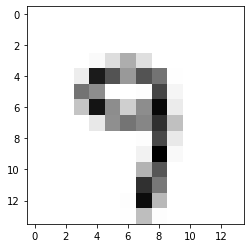

In [4]:
import matplotlib.pyplot as plt
plt.imshow(train_input[0,0],cmap='Greys')

# Convolutional Net

In [14]:
class BasicNet(nn.Module):
    def __init__(self):
        super(BasicNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=2, out_channels=64, kernel_size=2,stride=2,padding=1)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=2,stride=2,padding=1)
        self.conv3 = nn.Conv2d(in_channels=128,out_channels=64, kernel_size=2,stride=2,padding=0)
        self.conv4 = nn.Conv2d(in_channels=64,out_channels=32,kernel_size=2,stride=2,padding=1)
        self.fct = nn.Linear(32,2)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.fct(x.view(-1,128))
        return x

model = BasicNet()
repr(model)

'BasicNet(\n  (conv1): Conv2d(2, 64, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))\n  (conv2): Conv2d(64, 128, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))\n  (conv3): Conv2d(128, 64, kernel_size=(2, 2), stride=(2, 2))\n  (conv4): Conv2d(64, 32, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))\n  (fct): Linear(in_features=32, out_features=2, bias=True)\n)'

# Training

In [13]:
rounds = 1
train_model(model, train_input, train_target, test_input, test_target, rounds, validation=True, verbose=True)

RuntimeError: size mismatch, m1: [1000 x 128], m2: [32 x 2] at /Users/distiller/project/conda/conda-bld/pytorch_1579022061893/work/aten/src/TH/generic/THTensorMath.cpp:136

# Testing